# VIBeID A1 → MobileNetV3-Large 사전학습 (Colab Pro)

**목표**: VIBeID A1 (100명 CWT 이미지)로 backbone 사전학습 → Jetson에서 4인 데이터로 파인튜닝

**모델 선택 근거**:
- Jetson Orin Nano P3450 (40 TOPS, 8GB) 에서 CWT 전처리와 추론을 동시에 돌릴 마진 확보
- MobileNetV3-Large: 5.4M params, 0.22G FLOPs, ImageNet 75.2% — ResNet-18(11.7M, 1.8G, 69.8%) 대비 압도적으로 가벼우면서 ImageNet 성능은 더 좋음
- depthwise separable conv 구조라 TensorRT FP16/INT8 변환 시 가속 효과가 큼

**Pipeline**: Kaggle API → 데이터 다운 → MobileNetV3 학습 → Drive에 가중치 백업 → 4인 데이터 파인튜닝(다음 노트북) → ONNX → TensorRT(Jetson)

---

## 사전 준비
1. Kaggle 계정 → Account → Create New API Token → `kaggle.json` 다운로드
2. 첫 셀 실행하면 업로드 창 뜸 → `kaggle.json` 선택
3. Colab 런타임: **GPU (A100/V100/L4 권장)**, 고용량 RAM

## 1. Kaggle API 설정 & 데이터 다운로드

In [ ]:
# 1) 새 토큰 발급 (이전 토큰은 폐기 후) → 토큰 문자열 복사
# 2) 아래 변수에 붙여넣기

KAGGLE_TOKEN = "KGAT_c7be73333aeedb5c48c72460f5d21323"  # 예: "KGAT_xxxxxxxx..."

# 토큰 저장
import os
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/access_token'), 'w') as f:
    f.write(KAGGLE_TOKEN)
os.chmod(os.path.expanduser('~/.kaggle/access_token'), 0o600)

# kaggle 패키지 설치
!pip install -q kaggle

# 동작 확인
!kaggle datasets list -s vibeid


ref                       title                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------  ---------------  ----------  --------------------------  -------------  ---------  ---------------  
mainakml/vibeid-a1        VIBeID_A1        4135972669  2024-06-07 08:59:53.260000             25          0  0.1875           
vibeidiclr/vibeid-a4-2    VIBeID_A4_2        34854383  2024-10-06 07:20:27.790000              3          0  0.1875           
vibeidiclr/vibeid-a4-1    VIBeID_A4_1        69282298  2024-10-06 07:21:14.430000              2          0  0.1875           
vibeidiclr/vibeid-a2      VIBeID_A2        1837073245  2024-10-06 08:09:18.853000             11          0  0.1875           
vibeidiclr/vibeid-a3      VIBeID_A3        3839945440  2024-10-06 09:26:08.523000              5          0  0.1875           
mainakml/vibeid-a3-event  Vibeid_a3_event  1650081388  2024-06-10 03:49:22.543000              6          0  0.

In [ ]:
# VIBeID 데이터셋 다운로드
# Kaggle에서 'vibeid' 검색 → 데이터셋 페이지 URL 확인 → slug 입력
# 예: https://www.kaggle.com/datasets/abc123/vibeid-a1  →  KAGGLE_SLUG = 'abc123/vibeid-a1'

import os
os.makedirs('/content/data', exist_ok=True)

KAGGLE_SLUG = 'mainakml/vibeid-a1'  # ← 실제 slug로 교체

!kaggle datasets download -d {KAGGLE_SLUG} -p /content/data

# 압축 해제 (zip 파일명 확인 후 수정)
!ls /content/data
!unzip -q -o /content/data/*.zip -d /content/data/vibeid
!df -h /content

Dataset URL: https://www.kaggle.com/datasets/mainakml/vibeid-a1
License(s): CC-BY-NC-SA-4.0
100% 3.85G/3.85G [00:25<00:00, 164MB/s]

vibeid-a1.zip
Filesystem      Size  Used Avail Use% Mounted on
overlay         236G   51G  185G  22% /


In [ ]:
from pathlib import Path

A1_ROOT = Path('/content/data/vibeid/A1')
TRAIN_DIR = A1_ROOT / 'train'
TEST_DIR = A1_ROOT / 'test'

print(f'Train: {TRAIN_DIR}')
print(f'Test:  {TEST_DIR}')

# 검증
n_train_persons = len([p for p in TRAIN_DIR.iterdir() if p.is_dir()])
n_test_persons = len([p for p in TEST_DIR.iterdir() if p.is_dir()])
print(f'\nPersons - train: {n_train_persons}, test: {n_test_persons}')

Train: /content/data/vibeid/A1/train
Test:  /content/data/vibeid/A1/test

Persons - train: 100, test: 100


## 2. 라이브러리 & 환경

In [ ]:
import time
import random
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from PIL import Image

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('CUDA:', torch.cuda.get_device_name(0))
    print('VRAM:', torch.cuda.get_device_properties(0).total_memory / 1e9, 'GB')

Device: cuda
CUDA: NVIDIA A100-SXM4-40GB
VRAM: 42.405855232 GB


## 3. 데이터셋 클래스

사람 폴더(P1, P2, ...)를 라벨로. train/val에 다른 transform을 적용하기 위해 인덱스 분리 후 두 개의 dataset 객체 생성.

In [ ]:
from collections import Counter
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class VIBeIDDataset(Dataset):
    """VIBeID CWT 이미지 데이터셋.

    expected: split_dir/{0,1,2,...,99}/cwt_image_*.png
    """
    def __init__(self, split_dir, transform=None):
        self.split_dir = Path(split_dir)
        self.transform = transform

        # 사람 폴더 — 숫자순 정렬 (문자열 정렬하면 0, 1, 10, 11... 이 됨)
        person_dirs = sorted(
            [p for p in self.split_dir.iterdir() if p.is_dir()],
            key=lambda x: int(x.name)
        )
        self.classes = [p.name for p in person_dirs]
        self.cls2idx = {c: i for i, c in enumerate(self.classes)}

        # 모든 이미지 수집
        self.samples = []
        for p in person_dirs:
            for img in p.glob('*.png'):
                self.samples.append((str(img), self.cls2idx[p.name]))

        print(f'[{self.split_dir.name}] {len(self.classes)} classes, '
              f'{len(self.samples)} samples')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


# Transform — train만 augmentation
IMG_SIZE = 224

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    # ⚠️ CWT 이미지: 가로축=시간, 세로축=주파수 — flip 절대 금지
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Dataset 생성
train_ds = VIBeIDDataset(TRAIN_DIR, transform=train_tf)
val_ds   = VIBeIDDataset(TEST_DIR,  transform=val_tf)

# 클래스 일치 확인 — train과 test 클래스가 같은 인덱스인지
assert train_ds.classes == val_ds.classes, "Train/test class mismatch!"
NUM_CLASSES = len(train_ds.classes)
classes = train_ds.classes
print(f'\nNum classes: {NUM_CLASSES}')

# 클래스별 샘플 분포 확인
train_counts = Counter(lbl for _, lbl in train_ds.samples)
print(f'Train per-class — min: {min(train_counts.values())}, '
      f'max: {max(train_counts.values())}, '
      f'mean: {np.mean(list(train_counts.values())):.0f}')

# DataLoader
BATCH = 128
NUM_WORKERS = 4

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=True)
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True,
                        persistent_workers=True)

# 첫 배치 확인
imgs, lbls = next(iter(train_loader))
print(f'\nBatch shape: {imgs.shape}')
print(f'Labels (first 10): {lbls[:10].tolist()}')
print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

[train] 100 classes, 115458 samples
[test] 100 classes, 28913 samples

Num classes: 100
Train per-class — min: 358, max: 1774, mean: 1155

Batch shape: torch.Size([128, 3, 224, 224])
Labels (first 10): [96, 63, 79, 34, 23, 74, 79, 14, 23, 31]
Train batches: 903, Val batches: 226


## 4. 모델 — MobileNetV3-Large (ImageNet pretrained)

In [ ]:
def build_mobilenetv3(num_classes, pretrained=True, variant='large'):
    """MobileNetV3 with classifier replaced for `num_classes`."""
    if variant == 'large':
        weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V2 if pretrained else None
        model = models.mobilenet_v3_large(weights=weights)
        # classifier: [Linear(960, 1280), Hardswish, Dropout, Linear(1280, 1000)]
        in_feat = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(in_feat, num_classes)
    else:  # small
        weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if pretrained else None
        model = models.mobilenet_v3_small(weights=weights)
        in_feat = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(in_feat, num_classes)
    return model

model = build_mobilenetv3(NUM_CLASSES, pretrained=True, variant='large').to(device)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {n_params/1e6:.2f}M  (trainable: {n_trainable/1e6:.2f}M)')

# Forward 테스트
with torch.no_grad():
    out = model(imgs[:2].to(device))
    print(f'Output shape: {out.shape}')

Total params: 4.33M  (trainable: 4.33M)
Output shape: torch.Size([2, 100])


## 5. 학습 루프 (AMP + cosine schedule)

In [ ]:
EPOCHS = 15
LR = 3e-4              # MobileNet은 ResNet보다 약간 작은 LR이 안정적
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.1     # 100-class라 약간 도움

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler()

def run_epoch(model, loader, train=True):
    model.train(train)
    total, correct, loss_sum = 0, 0, 0.0
    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast():
            logits = model(imgs)
            loss = criterion(logits, labels)

        if train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        loss_sum += loss.item() * imgs.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += imgs.size(0)

    return loss_sum / total, correct / total

/tmp/ipykernel_4336/2251651995.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
best_acc = 0.0
history = []
save_path = '/content/mobilenetv3_vibeid_a1_best.pth'

for ep in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model, train_loader, train=True)
    with torch.no_grad():
        val_loss, val_acc = run_epoch(model, val_loader, train=False)
    scheduler.step()
    dt = time.time() - t0

    history.append((ep, tr_loss, tr_acc, val_loss, val_acc))
    print(f'[{ep:02d}/{EPOCHS}] '
          f'train {tr_loss:.4f}/{tr_acc*100:.2f}%  '
          f'val {val_loss:.4f}/{val_acc*100:.2f}%  '
          f'lr {scheduler.get_last_lr()[0]:.2e}  '
          f'({dt:.1f}s)')

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            'epoch': ep,
            'model_state_dict': model.state_dict(),
            'classes': classes,
            'val_acc': val_acc,
            'arch': 'mobilenet_v3_large',
            'num_classes': NUM_CLASSES,
            'img_size': IMG_SIZE,
        }, save_path)
        print(f'  ✓ saved (best val_acc={best_acc*100:.2f}%)')

print(f'\nBest val acc: {best_acc*100:.2f}%')

/tmp/ipykernel_4336/2251651995.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[01/15] train 2.2790/51.01%  val 2.4103/46.31%  lr 2.97e-04  (162.2s)
  ✓ saved (best val_acc=46.31%)
[02/15] train 1.6086/71.91%  val 1.7596/66.25%  lr 2.87e-04  (160.9s)
  ✓ saved (best val_acc=66.25%)
[03/15] train 1.4376/77.86%  val 1.7191/68.41%  lr 2.71e-04  (161.1s)
  ✓ saved (best val_acc=68.41%)
[04/15] train 1.3346/81.59%  val 1.4785/75.73%  lr 2.50e-04  (160.3s)
  ✓ saved (best val_acc=75.73%)
[05/15] train 1.2579/84.32%  val 1.6192/71.43%  lr 2.25e-04  (161.5s)
[06/15] train 1.1892/86.95%  val 1.3610/80.17%  lr 1.96e-04  (160.4s)
  ✓ saved (best val_acc=80.17%)
[07/15] train 1.1274/89.39%  val 1.3991/79.14%  lr 1.66e-04  (160.9s)
[08/15] train 1.0710/91.56%  val 1.3382/81.74%  lr 1.34e-04  (161.4s)
  ✓ saved (best val_acc=81.74%)
[09/15] train 1.0202/93.62%  val 1.3184/82.37%  lr 1.04e-04  (160.4s)
  ✓ saved (best val_acc=82.37%)
[10/15] train 0.9706/95.73%  val 1.3013/83.16%  lr 7.50e-05  (161.3s)
  ✓ saved (best val_acc=83.16%)
[11/15] train 0.9377/97.03%  val 1.2868/83.7

## 6. 학습 곡선

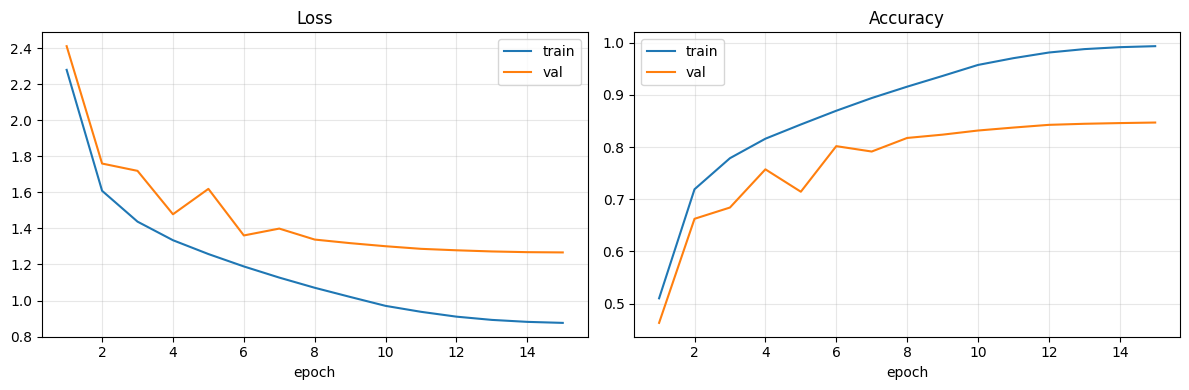

In [ ]:
import matplotlib.pyplot as plt

ep_x = [h[0] for h in history]
tr_l = [h[1] for h in history]; tr_a = [h[2] for h in history]
va_l = [h[3] for h in history]; va_a = [h[4] for h in history]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ep_x, tr_l, label='train'); ax[0].plot(ep_x, va_l, label='val')
ax[0].set_title('Loss'); ax[0].set_xlabel('epoch')
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(ep_x, tr_a, label='train'); ax[1].plot(ep_x, va_a, label='val')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('epoch')
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Confusion Matrix (best 모델 로드 후)

In [ ]:
# 100개 클래스라 cm 자체는 안 보겠지만, 클래스별 정확도는 의미 있음
ckpt = torch.load(save_path, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

all_preds, all_lbls = [], []
with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_lbls.extend(lbls.numpy().tolist())

all_preds = np.array(all_preds); all_lbls = np.array(all_lbls)

# 클래스별 정확도
per_class_acc = []
for c in range(NUM_CLASSES):
    mask = all_lbls == c
    if mask.sum() > 0:
        per_class_acc.append((classes[c], (all_preds[mask] == c).mean()))

per_class_acc.sort(key=lambda x: x[1])
print('Worst 5 classes:')
for n, a in per_class_acc[:5]:
    print(f'  {n}: {a*100:.2f}%')
print('\nBest 5 classes:')
for n, a in per_class_acc[-5:]:
    print(f'  {n}: {a*100:.2f}%')

Worst 5 classes:
  72: 58.09%
  67: 59.22%
  30: 64.24%
  51: 65.02%
  71: 65.54%

Best 5 classes:
  2: 97.94%
  64: 98.95%
  93: 99.15%
  55: 99.65%
  4: 100.00%


## 8. Drive에 가중치 백업

런타임 종료 시 `/content`는 사라짐. 가중치(`.pth`)는 수십 MB라 Drive에 충분히 들어감.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/vibeid_capstone/weights'
!mkdir -p {DRIVE_DIR}
!cp {save_path} {DRIVE_DIR}/
!ls -lh {DRIVE_DIR}/

Mounted at /content/drive
total 17M
-rw------- 1 root root 17M Apr 28 11:36 mobilenetv3_vibeid_a1_best.pth


## 9. (다음 단계) 4인 데이터 파인튜닝 골격

Jetson에서 4명 보행 데이터를 수집해 CWT 이미지로 변환한 뒤, 아래 코드로 파인튜닝.

In [ ]:
# 다음 노트북에서 사용할 코드 미리보기 — 지금은 실행하지 말 것
"""
# 1) 사전학습 가중치 로드
ckpt = torch.load(f'{DRIVE_DIR}/mobilenetv3_vibeid_a1_best.pth')

# 2) backbone 로드 후 classifier만 4-class로 교체
model_ft = build_mobilenetv3(num_classes=ckpt['num_classes'], pretrained=False, variant='large')
model_ft.load_state_dict(ckpt['model_state_dict'])

# classifier 마지막 Linear만 4-class로
in_feat = model_ft.classifier[3].in_features
model_ft.classifier[3] = nn.Linear(in_feat, 4)
model_ft = model_ft.to(device)

# 3) 논문 권장 - 마지막 부분만 fine-tune (데이터 적을 때 안정)
for p in model_ft.parameters():
    p.requires_grad = False
# MobileNetV3 features의 마지막 block + classifier만 unfreeze
for p in model_ft.features[-3:].parameters():  # 마지막 3 블록
    p.requires_grad = True
for p in model_ft.classifier.parameters():
    p.requires_grad = True

# 4) 작은 LR (1e-4) + 적은 epoch (10~15)
optimizer_ft = optim.AdamW(
    [p for p in model_ft.parameters() if p.requires_grad],
    lr=1e-4, weight_decay=1e-4
)
"""
print('See comment above for fine-tuning template.')

## 10. (Jetson 배포 준비) ONNX export

파인튜닝까지 끝나면 ONNX → TensorRT(Jetson).

In [ ]:
# 파인튜닝 끝난 후에 실행 - 지금 단계에서는 사전학습 모델 export 테스트용
model.eval()
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
onnx_path = '/content/mobilenetv3_vibeid_a1.onnx'

torch.onnx.export(
    model, dummy, onnx_path,
    input_names=['input'], output_names=['logits'],
    dynamic_axes={'input': {0: 'batch'}, 'logits': {0: 'batch'}},
    opset_version=13,
    do_constant_folding=True,
)

import os as _os
print(f'ONNX exported: {onnx_path}  ({_os.path.getsize(onnx_path)/1e6:.2f} MB)')

# Drive에도 백업
!cp {onnx_path} {DRIVE_DIR}/